In [1]:
from wavediffusion.model_unet import myUnet
from wavediffusion.model import Scaled
import os
import numpy as np
import torch
from torch_ema import ExponentialMovingAverage as EMA
from wavediffusion.wavedata import npyDataWndHist
from accelerate import Accelerator

OPTION = 1
epoch = 8
model_path = f'/global/homes/j/jiarongw/scratch_folder/final/OPTION{OPTION}/'
weights_file = model_path + f'ckpt_{epoch}.pt'
test_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/mean_global/'
stats_file = os.path.join(test_file_path, f'stats_OPTION{OPTION}.npz')
stats = np.load(stats_file)
meanx, stdx = stats['meanx'], stats['stdx']
meanf, stdf = stats['meanf'], stats['stdf']
test_file_names = [('wavemean_200404', 'forcing_200404')]
test_file_list = [(os.path.join(test_file_path, f'{x}.npy'), 
                   os.path.join(test_file_path, f'{f}.npy')) for x, f in test_file_names]
test = npyDataWndHist(
    test_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(test_file_path, 'mask.npy'),
    use_icymask=True, compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf,
    OPTION=OPTION
)

model = Scaled(myUnet)(in_dim=320, in_ch=3, out_ch=3, ch=256, precond_ch=14, 
                   scale=(test.meanx, test.stdx, test.meanf, test.stdf),
                   ch_mult=(1, 2, 2), attn_resolutions=(16,))

ema = EMA(model.parameters(), decay=0.999)
ckpt = torch.load(weights_file, map_location="cpu")
model.load_state_dict(ckpt["model"])
ema.load_state_dict(ckpt["ema"])
a = Accelerator()
model = a.prepare(model)
ema.to(a.device)

In [4]:
array = np.load(test_file_path + 'wavemean_200404.npy', mmap_mode="r")

In [5]:
array.shape

(240, 9, 320, 720)

In [7]:
test.__len__()

199

In [60]:
x, f, mask = test.__getitem__(idx=0)
x = x.unsqueeze(0)
f = f.unsqueeze(0)

## Setup
Configure the target pixel and UNet architecture parameters.

In [47]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Target output pixel to analyze
TARGET_I = 140   # row index in 320x320 output
TARGET_J = 160   # col index in 320x320 output
OUT_CH   = 1     # output channel

# UNet architecture (must match loaded model)
IN_DIM       = 320
IN_CH        = 3
PRECOND_CH   = 14
CH_MULT      = (1, 2, 2)
NUM_RES_BLOCKS   = 2
ATTN_RESOLUTIONS = (16,)

## Method 1: Gradient-based Effective Receptive Field (ERF)

Backpropagate from a single output pixel to measure how much each input pixel influences it.

- Use `sigma=0` so the `Scaled` wrapper applies a factor of `alpha(0).sqrt() = 1` (no distortion).
- Gradient magnitude `|∂output[i,j] / ∂input|` reveals the effective influence map.

In [74]:
def gradient_erf(model, target_i, target_j, x, cond, out_ch=0, device='cpu', wrt='cond'):
    model.eval()
    sigma = torch.tensor(1, device=device)

    x    = x.to(device).detach().requires_grad_(wrt == 'x')
    cond = cond.to(device).detach().requires_grad_(wrt == 'cond')

    out = model(x, sigma, cond=cond)
    model.zero_grad()
    out[0, out_ch, target_i, target_j].backward()

    target = cond if wrt == 'cond' else x

    assert target.grad is not None, \
        "Gradient is None — check that the target is used in the forward pass"

    erf = target.grad.data.abs().squeeze(0).cpu().numpy()
    return erf

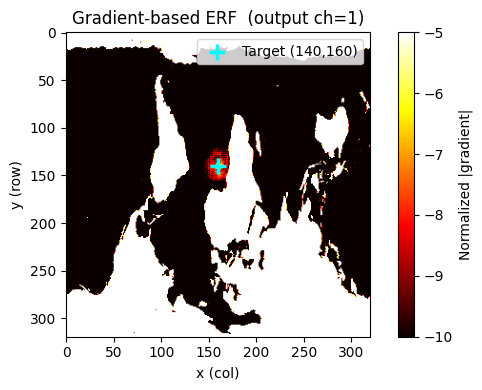

In [75]:
device = a.device
erf = gradient_erf(model, TARGET_I, TARGET_J, x, f, out_ch=2, device=device, wrt='cond')

fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
im = ax.imshow(np.log(erf[0])*mask[0].numpy(), cmap='hot', origin='upper', vmax=-5, vmin=-10)
ax.scatter(TARGET_J, TARGET_I, c='cyan', s=120, marker='+',
           linewidths=2.5, label=f'Target ({TARGET_I},{TARGET_J})')
ax.set_title(f'Gradient-based ERF  (output ch={OUT_CH})')
ax.set_xlabel('x (col)')
ax.set_ylabel('y (row)')
plt.colorbar(im, ax=ax, label='Normalized |gradient|')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

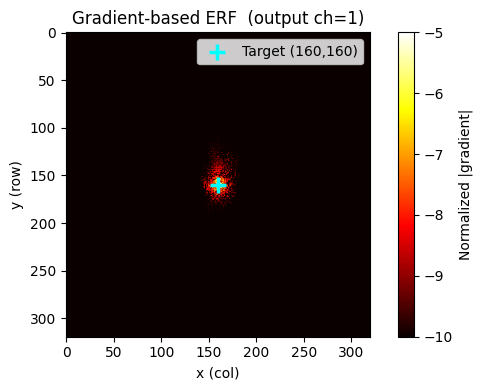

In [37]:
device = a.device
erf = gradient_erf(model, TARGET_I, TARGET_J, out_ch=OUT_CH,
                   in_dim=IN_DIM, in_ch=IN_CH, precond_ch=PRECOND_CH, device=device, wrt='cond')

fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
im = ax.imshow(np.log(erf[0]), cmap='hot', origin='upper', vmax=-5, vmin=-10)
ax.scatter(TARGET_J, TARGET_I, c='cyan', s=120, marker='+',
           linewidths=2.5, label=f'Target ({TARGET_I},{TARGET_J})')
ax.set_title(f'Gradient-based ERF  (output ch={OUT_CH})')
ax.set_xlabel('x (col)')
ax.set_ylabel('y (row)')
plt.colorbar(im, ax=ax, label='Normalized |gradient|')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Method 2: Analytical Receptive Field

Trace the receptive field through each layer type using the standard formula:

$$r_{\text{new}} = r + (k-1) \cdot j, \qquad j_{\text{new}} = j \cdot s$$

where $r$ = current RF size, $j$ = jump (input-space stride), $k$ = kernel size, $s$ = stride.

**Two regimes:**
- **Conv-only RF**: finite rectangular region, computed ignoring the self-attention block.
- **Full RF**: after global self-attention in the bottleneck every output pixel attends to all 80×80 bottleneck positions, giving access to the **entire input** (320×320).

In [5]:
def compute_analytical_rf(in_dim, ch_mult, num_res_blocks,
                           attn_resolutions=(), include_attention=False):
    """
    Compute the receptive field of a single output pixel for a symmetric UNet
    (same-resolution input/output) using the jump/RF recurrence.

    Parameters
    ----------
    include_attention : bool
        If True, the middle self-attention block sets r = in_dim (global).
        If False, treat the attention block as a no-op for RF purposes.

    Returns
    -------
    rf : int  –  receptive field size (clamped to in_dim)
    skip_rfs : dict[level -> (rf, jump, resolution)]  –  encoder skip RFs
    """
    CONVS_PER_BLOCK = 2
    num_resolutions = len(ch_mult)

    r, j = 1, 1
    curr_res = in_dim

    # conv_in  (k=3, s=1)
    r += (3 - 1) * j

    # ---- Encoder ----
    skip_rfs = {}
    for i in range(num_resolutions):
        attn = curr_res in attn_resolutions
        for _ in range(num_res_blocks):
            for _ in range(CONVS_PER_BLOCK):
                r += (3 - 1) * j
            if attn and include_attention:
                r = in_dim
        skip_rfs[i] = (r, j, curr_res)
        if i < num_resolutions - 1:
            r += (3 - 1) * j          # Downsample: ConstantPad + Conv(k=3, s=2)
            j *= 2
            curr_res //= 2

    # ---- Middle ----
    for _ in range(CONVS_PER_BLOCK):  # first ResnetBlock
        r += (3 - 1) * j
    if include_attention:             # global self-attention
        r = in_dim
    for _ in range(CONVS_PER_BLOCK):  # second ResnetBlock
        r += (3 - 1) * j

    # ---- Decoder ----
    for i_level in range(num_resolutions):
        enc_level = num_resolutions - 1 - i_level
        r_skip, _, _ = skip_rfs[enc_level]
        attn = curr_res in attn_resolutions

        for _ in range(num_res_blocks + 1):  # +1 because of extra skip block
            r = max(r, r_skip)               # skip connection widens RF
            for _ in range(CONVS_PER_BLOCK):
                r += (3 - 1) * j
            if attn and include_attention:
                r = in_dim

        if i_level < num_resolutions - 1:
            # Upsample = nn.Upsample(scale=2) + Conv(k=3, s=1)
            j //= 2
            r += (3 - 1) * j
            curr_res *= 2

    # out_layer conv  (k=3, s=1)
    r += (3 - 1) * j

    return min(r, in_dim), skip_rfs


rf_conv, skip_rfs = compute_analytical_rf(
    IN_DIM, CH_MULT, NUM_RES_BLOCKS,
    attn_resolutions=ATTN_RESOLUTIONS, include_attention=False
)
rf_full, _ = compute_analytical_rf(
    IN_DIM, CH_MULT, NUM_RES_BLOCKS,
    attn_resolutions=ATTN_RESOLUTIONS, include_attention=True
)

print(f"Conv-only RF (ignoring attention) : {rf_conv} × {rf_conv} pixels")
print(f"RF with global attention in middle: {rf_full} × {rf_full} pixels  (= full field)")
print()
print("Encoder skip RFs at each level:")
for lvl, (r_s, j_s, res_s) in skip_rfs.items():
    print(f"  Level {lvl}  (res={res_s}): RF = {r_s}, jump = {j_s}")

Conv-only RF (ignoring attention) : 189 × 189 pixels
RF with global attention in middle: 320 × 320 pixels  (= full field)

Encoder skip RFs at each level:
  Level 0  (res=320): RF = 11, jump = 1
  Level 1  (res=160): RF = 29, jump = 2
  Level 2  (res=80): RF = 65, jump = 4


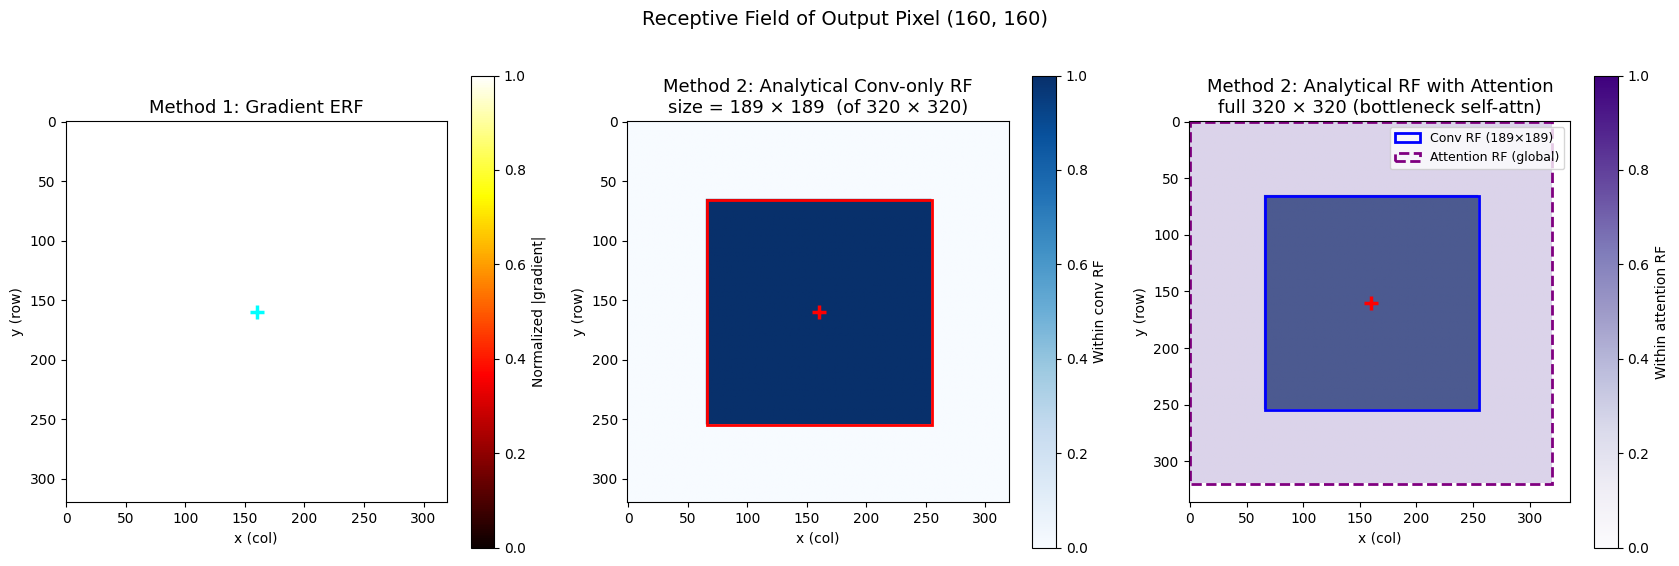

In [6]:
def rf_box(target_i, target_j, rf_size, in_dim):
    """Return (r0,r1,c0,c1) bounding box for an rf_size × rf_size receptive field."""
    half = rf_size // 2
    r0 = max(0, target_i - half)
    r1 = min(in_dim, target_i + half + 1)
    c0 = max(0, target_j - half)
    c1 = min(in_dim, target_j + half + 1)
    return r0, r1, c0, c1


fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# --- Panel 1: gradient ERF ---
ax = axes[0]
im0 = ax.imshow(erf, cmap='hot', origin='upper', vmin=0, vmax=1)
ax.scatter(TARGET_J, TARGET_I, c='cyan', s=100, marker='+', linewidths=2.5, zorder=5)
ax.set_title('Method 1: Gradient ERF', fontsize=13)
ax.set_xlabel('x (col)'); ax.set_ylabel('y (row)')
plt.colorbar(im0, ax=ax, label='Normalized |gradient|')

# --- Panel 2: conv-only analytical RF ---
ax = axes[1]
r0, r1, c0, c1 = rf_box(TARGET_I, TARGET_J, rf_conv, IN_DIM)
rf_map = np.zeros((IN_DIM, IN_DIM))
rf_map[r0:r1, c0:c1] = 1.0
ax.imshow(rf_map, cmap='Blues', origin='upper', vmin=0, vmax=1)
rect = patches.Rectangle((c0, r0), c1 - c0, r1 - r0,
                          linewidth=2, edgecolor='red', facecolor='none')
ax.add_patch(rect)
ax.scatter(TARGET_J, TARGET_I, c='red', s=100, marker='+', linewidths=2.5, zorder=5)
ax.set_title(f'Method 2: Analytical Conv-only RF\n'
             f'size = {rf_conv} × {rf_conv}  (of {IN_DIM} × {IN_DIM})', fontsize=13)
ax.set_xlabel('x (col)'); ax.set_ylabel('y (row)')
plt.colorbar(plt.cm.ScalarMappable(norm=None, cmap='Blues'),
             ax=ax, label='Within conv RF')

# --- Panel 3: analytical RF with attention (global) ---
ax = axes[2]
full_map = np.ones((IN_DIM, IN_DIM))
ax.imshow(full_map, cmap='Purples', origin='upper', vmin=0, vmax=1, alpha=0.4)
# overlay conv RF for reference
rf_map2 = np.zeros((IN_DIM, IN_DIM))
rf_map2[r0:r1, c0:c1] = 1.0
ax.imshow(rf_map2, cmap='Blues', origin='upper', vmin=0, vmax=1, alpha=0.6)
rect2 = patches.Rectangle((c0, r0), c1 - c0, r1 - r0,
                           linewidth=2, edgecolor='blue', facecolor='none',
                           label=f'Conv RF ({rf_conv}×{rf_conv})')
ax.add_patch(rect2)
rect3 = patches.Rectangle((0, 0), IN_DIM, IN_DIM,
                           linewidth=2, edgecolor='purple', facecolor='none',
                           linestyle='--', label='Attention RF (global)')
ax.add_patch(rect3)
ax.scatter(TARGET_J, TARGET_I, c='red', s=100, marker='+', linewidths=2.5, zorder=5)
ax.set_title(f'Method 2: Analytical RF with Attention\n'
             f'full {IN_DIM} × {IN_DIM} (bottleneck self-attn)', fontsize=13)
ax.set_xlabel('x (col)'); ax.set_ylabel('y (row)')
ax.legend(loc='upper right', fontsize=9)
plt.colorbar(plt.cm.ScalarMappable(norm=None, cmap='Purples'),
             ax=ax, label='Within attention RF')

plt.suptitle(f'Receptive Field of Output Pixel ({TARGET_I}, {TARGET_J})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('receptive_field.png', dpi=150, bbox_inches='tight')
plt.show()